ValueError: 'inherit' is not a valid color value.

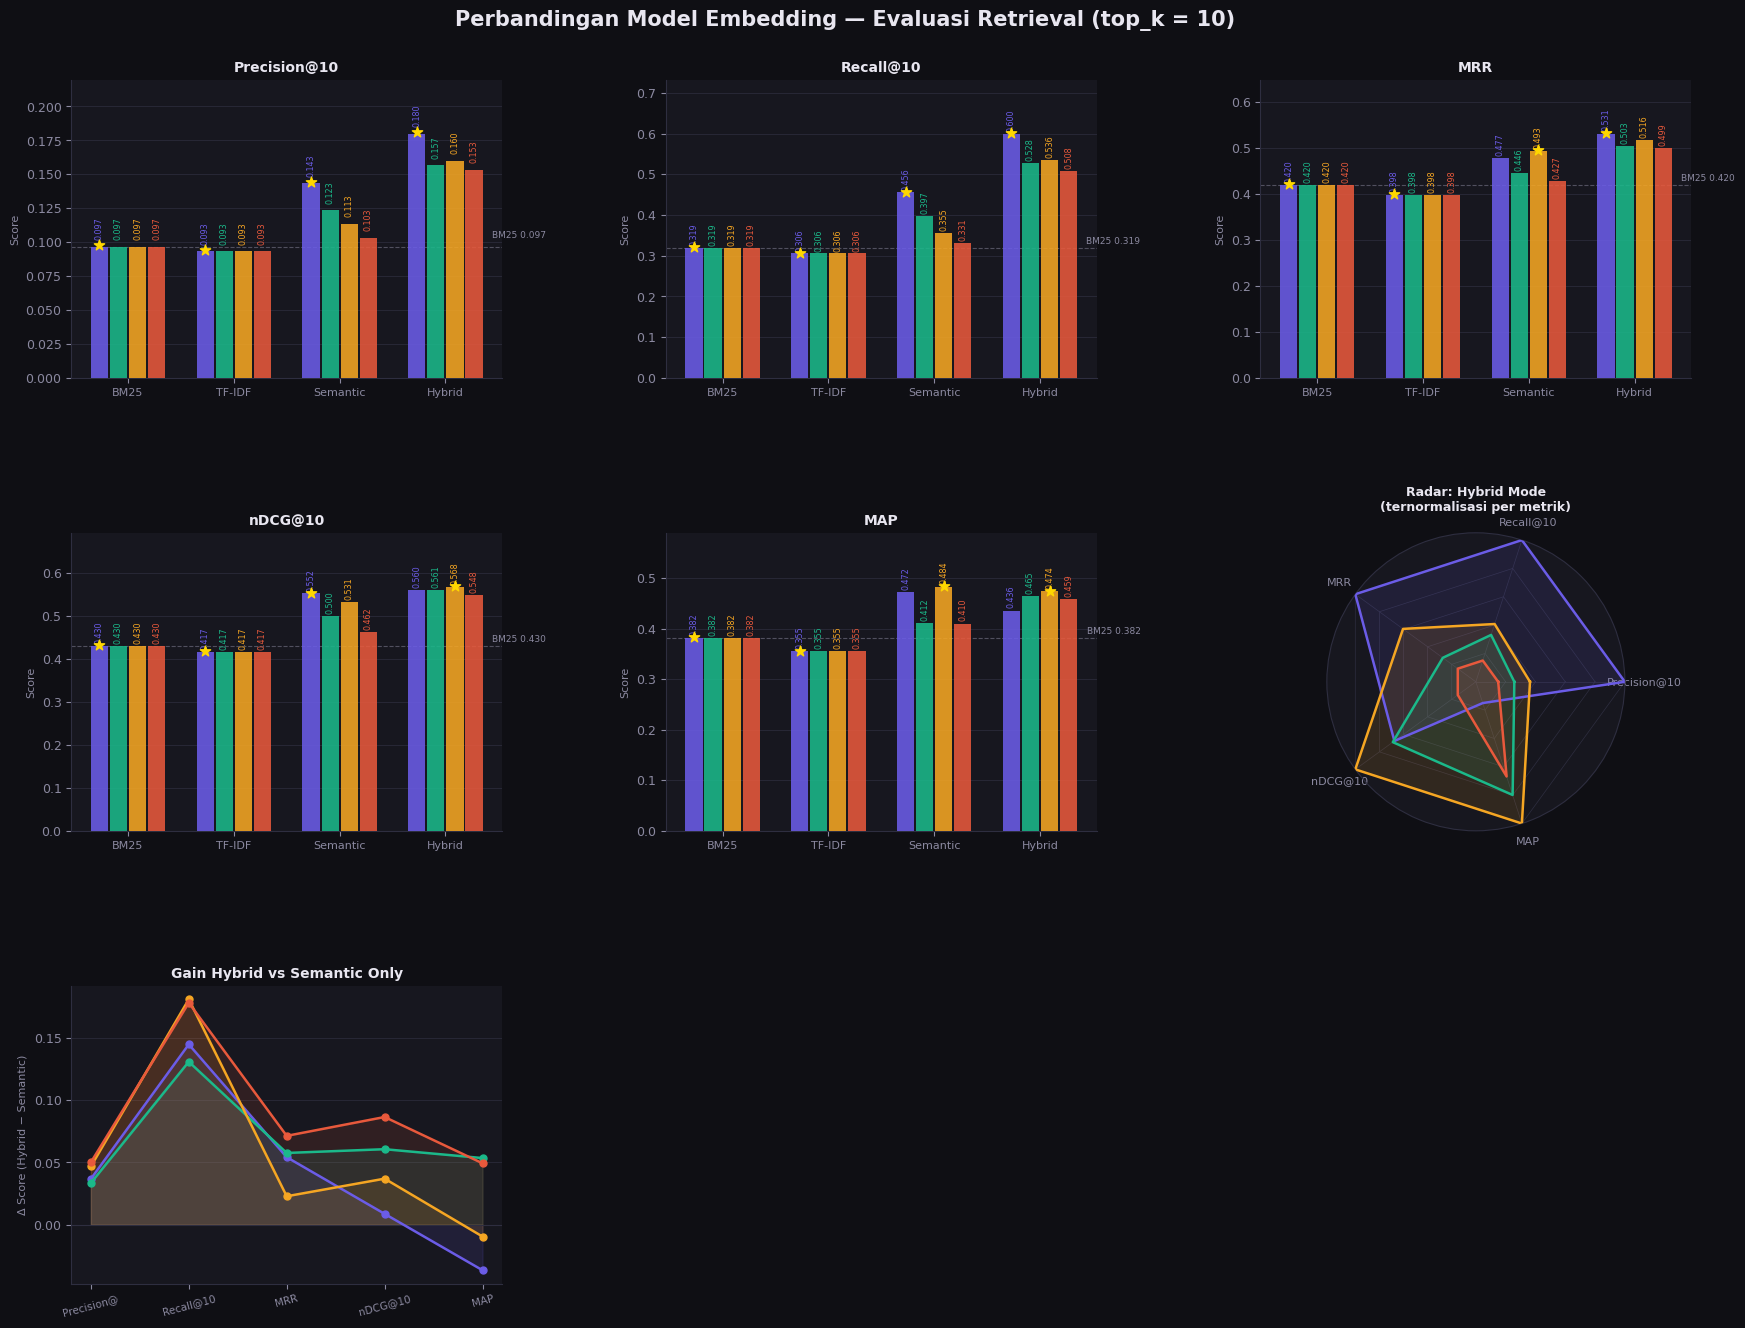

In [1]:
"""
Visualisasi Perbandingan Model Embedding — Evaluasi Retrieval
=============================================================
Menampilkan perbandingan 4 model embedding (BGE-M3, Indo-SentenceBERT,
Multilingual-E5, MiniLM-L12-v2) lintas 4 metode retrieval dan 5 metrik.

Dependencies:
    pip install matplotlib numpy
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

# ──────────────────────────────────────────────
# DATA
# ──────────────────────────────────────────────

MODELS = {
    "BGE-M3":            {"short": "BGE-M3",   "color": "#6B5CE7"},
    "Indo-SentenceBERT": {"short": "Indo-BERT", "color": "#1BB98A"},
    "Multilingual-E5":   {"short": "mE5",       "color": "#F5A623"},
    "MiniLM-L12-v2":     {"short": "MiniLM",    "color": "#E8593C"},
}

METHODS = ["BM25", "TF-IDF", "Semantic", "Hybrid"]

METRICS = ["Precision@10", "Recall@10", "MRR", "nDCG@10", "MAP"]

# data[model][metric] = [bm25, tfidf, semantic, hybrid]
DATA = {
    "BGE-M3": {
        "Precision@10": [0.0967, 0.0933, 0.1433, 0.1800],
        "Recall@10":    [0.3194, 0.3056, 0.4555, 0.6000],
        "MRR":          [0.4198, 0.3981, 0.4768, 0.5309],
        "nDCG@10":      [0.4302, 0.4166, 0.5517, 0.5604],
        "MAP":          [0.3817, 0.3553, 0.4722, 0.4357],
    },
    "Indo-SentenceBERT": {
        "Precision@10": [0.0967, 0.0933, 0.1233, 0.1567],
        "Recall@10":    [0.3194, 0.3056, 0.3972, 0.5278],
        "MRR":          [0.4198, 0.3981, 0.4459, 0.5034],
        "nDCG@10":      [0.4302, 0.4166, 0.5002, 0.5607],
        "MAP":          [0.3817, 0.3553, 0.4116, 0.4650],
    },
    "Multilingual-E5": {
        "Precision@10": [0.0967, 0.0933, 0.1133, 0.1600],
        "Recall@10":    [0.3194, 0.3056, 0.3555, 0.5361],
        "MRR":          [0.4198, 0.3981, 0.4931, 0.5159],
        "nDCG@10":      [0.4302, 0.4166, 0.5309, 0.5678],
        "MAP":          [0.3817, 0.3553, 0.4836, 0.4741],
    },
    "MiniLM-L12-v2": {
        "Precision@10": [0.0967, 0.0933, 0.1033, 0.1533],
        "Recall@10":    [0.3194, 0.3056, 0.3305, 0.5083],
        "MRR":          [0.4198, 0.3981, 0.4275, 0.4987],
        "nDCG@10":      [0.4302, 0.4166, 0.4621, 0.5484],
        "MAP":          [0.3817, 0.3553, 0.4099, 0.4591],
    },
}

# ──────────────────────────────────────────────
# STYLE
# ──────────────────────────────────────────────

BG       = "#0F0F14"
BG2      = "#17171F"
SURFACE  = "#1E1E2A"
BORDER   = "#2E2E40"
TEXT_PRI = "#E8E6F0"
TEXT_SEC = "#8B89A0"
ACCENT   = "#6B5CE7"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG2,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT_SEC,
    "xtick.color":       TEXT_SEC,
    "ytick.color":       TEXT_SEC,
    "text.color":        TEXT_PRI,
    "grid.color":        BORDER,
    "grid.linewidth":    0.5,
    "font.family":       "DejaVu Sans",
    "font.size":         9,
})

def hex_alpha(hex_color, alpha=0.15):
    """Return RGBA tuple from hex + alpha."""
    h = hex_color.lstrip("#")
    r, g, b = (int(h[i:i+2], 16) / 255 for i in (0, 2, 4))
    return (r, g, b, alpha)


# ──────────────────────────────────────────────
# FIGURE LAYOUT
# ──────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle(
    "Perbandingan Model Embedding — Evaluasi Retrieval (top_k = 10)",
    fontsize=15, fontweight="bold", color=TEXT_PRI, y=0.98
)

gs = GridSpec(
    3, 3,
    figure=fig,
    hspace=0.52,
    wspace=0.38,
    top=0.93,
    bottom=0.07,
    left=0.07,
    right=0.97,
)

model_names  = list(MODELS.keys())
model_colors = [MODELS[m]["color"] for m in model_names]
model_shorts = [MODELS[m]["short"] for m in model_names]
n_models     = len(model_names)
n_methods    = len(METHODS)


# ──────────────────────────────────────────────
# 1. GROUPED BAR — per metrik (5 panel, top 2 rows)
# ──────────────────────────────────────────────

bar_positions = [
    (0, 0), (0, 1), (0, 2),
    (1, 0), (1, 1),
]

for idx, metric in enumerate(METRICS):
    row, col = bar_positions[idx]
    ax = fig.add_subplot(gs[row, col])

    x      = np.arange(n_methods)
    width  = 0.18
    offset = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

    for i, model in enumerate(model_names):
        vals = DATA[model][metric]
        bars = ax.bar(
            x + offset[i], vals,
            width=width * 0.9,
            color=model_colors[i],
            alpha=0.88,
            zorder=3,
        )
        # nilai di atas bar
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}",
                ha="center", va="bottom",
                fontsize=5.8,
                color=model_colors[i],
                rotation=90,
            )

    # Garis BM25 baseline (rata-rata semua model = sama)
    bm25_val = DATA[model_names[0]][metric][0]
    ax.axhline(bm25_val, color=TEXT_SEC, linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)
    ax.text(
        n_methods - 0.05, bm25_val + 0.005,
        f"BM25 {bm25_val:.3f}",
        fontsize=6.5, color=TEXT_SEC, ha="right", va="bottom"
    )

    # Mark nilai tertinggi di tiap metode
    for j, method in enumerate(METHODS):
        col_vals = [DATA[m][metric][j] for m in model_names]
        best_idx = int(np.argmax(col_vals))
        ax.scatter(
            x[j] + offset[best_idx],
            col_vals[best_idx] + 0.001,
            marker="*", s=60,
            color="#FFD700",
            zorder=5,
        )

    ax.set_title(metric, fontsize=10, fontweight="bold", color=TEXT_PRI, pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(METHODS, fontsize=8)
    ax.set_ylabel("Score", fontsize=8)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)

    ymax = max(DATA[m][metric][j] for m in model_names for j in range(n_methods))
    ax.set_ylim(0, ymax * 1.22)
    ax.spines[["top", "right"]].set_visible(False)


# ──────────────────────────────────────────────
# 2. RADAR — Hybrid mode, semua metrik
# ──────────────────────────────────────────────

ax_radar = fig.add_subplot(gs[1, 2], polar=True)

categories = METRICS
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

ax_radar.set_facecolor(BG2)
ax_radar.spines["polar"].set_edgecolor(BORDER)

# Grid rings
for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax_radar.plot(angles, [r] * (N + 1), color=BORDER, linewidth=0.5, zorder=1)

# Spoke labels
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=8, color=TEXT_SEC)
ax_radar.set_yticks([])
ax_radar.set_ylim(0, 1)

# Normalisasi per metrik → [0, 1] berdasarkan range data hybrid
hybrid_idx = 3
all_hybrid = {
    m: [DATA[m][met][hybrid_idx] for met in METRICS]
    for m in model_names
}
mins_h = [min(all_hybrid[m][i] for m in model_names) for i in range(N)]
maxs_h = [max(all_hybrid[m][i] for m in model_names) for i in range(N)]

for model in model_names:
    raw   = [DATA[model][met][hybrid_idx] for met in METRICS]
    normd = [
        (v - mn) / (mx - mn) if mx > mn else 0.5
        for v, mn, mx in zip(raw, mins_h, maxs_h)
    ]
    normd = [0.15 + 0.85 * v for v in normd]  # floor 0.15 agar visible
    normd += normd[:1]

    color = MODELS[model]["color"]
    ax_radar.plot(angles, normd, color=color, linewidth=1.8, zorder=3)
    ax_radar.fill(angles, normd, color=color, alpha=0.12, zorder=2)

ax_radar.set_title("Radar: Hybrid Mode\n(ternormalisasi per metrik)",
                   fontsize=9, fontweight="bold", color=TEXT_PRI,
                   pad=14, va="bottom")


# ──────────────────────────────────────────────
# 3. LINE PLOT — Semantic vs Hybrid improvement
# ──────────────────────────────────────────────

ax_line = fig.add_subplot(gs[2, 0])

sem_idx = 2

for model in model_names:
    color  = MODELS[model]["color"]
    short  = MODELS[model]["short"]
    sem_v  = [DATA[model][met][sem_idx]    for met in METRICS]
    hyb_v  = [DATA[model][met][hybrid_idx] for met in METRICS]
    delta  = [h - s for h, s in zip(hyb_v, sem_v)]

    x_pos = np.arange(N)
    ax_line.plot(x_pos, delta, color=color, linewidth=1.8,
                 marker="o", markersize=5, label=short, zorder=3)
    ax_line.fill_between(x_pos, delta, 0,
                         color=hex_alpha(color, 0.12), zorder=2)

ax_line.axhline(0, color=BORDER, linewidth=0.8)
ax_line.set_xticks(np.arange(N))
ax_line.set_xticklabels([m[:10] for m in METRICS], fontsize=7.5, rotation=15)
ax_line.set_ylabel("Δ Score (Hybrid − Semantic)", fontsize=8)
ax_line.set_title("Gain Hybrid vs Semantic Only", fontsize=10,
                  fontweight="bold", color=TEXT_PRI, pad=6)
ax_line.grid(axis="y", zorder=0)
ax_line.set_axisbelow(True)
ax_line.spines[["top", "right"]].set_visible(False)
ax_line.legend(fontsize=7.5, framealpha=0, labelcolor="inherit",
               loc="upper right")


# ──────────────────────────────────────────────
# 4. HEATMAP — Semua model × semua metode, per metrik
#    (disusun sebagai satu heatmap besar: baris=model×metrik, kolom=metode)
# ──────────────────────────────────────────────

ax_heat = fig.add_subplot(gs[2, 1:])

n_rows = n_models * len(METRICS)
matrix = np.zeros((n_rows, n_methods))
row_labels = []

for mi, metric in enumerate(METRICS):
    for ki, model in enumerate(model_names):
        r = mi * n_models + ki
        matrix[r] = DATA[model][metric]
        row_labels.append(f"{MODELS[model]['short']} – {metric[:8]}")

# Normalisasi baris
row_min = matrix.min(axis=1, keepdims=True)
row_max = matrix.max(axis=1, keepdims=True)
matrix_n = np.where(
    row_max > row_min,
    (matrix - row_min) / (row_max - row_min),
    0.5
)

im = ax_heat.imshow(matrix_n, aspect="auto", cmap="RdYlGn",
                    vmin=0, vmax=1, interpolation="nearest")

# Separator antara metrik
for mi in range(1, len(METRICS)):
    y_sep = mi * n_models - 0.5
    ax_heat.axhline(y_sep, color=BG, linewidth=2)

ax_heat.set_xticks(np.arange(n_methods))
ax_heat.set_xticklabels(METHODS, fontsize=9)
ax_heat.set_yticks(np.arange(n_rows))
ax_heat.set_yticklabels(row_labels, fontsize=7)
ax_heat.set_title("Heatmap Skor (ternormalisasi per baris — merah=rendah, hijau=tinggi)",
                  fontsize=9, fontweight="bold", color=TEXT_PRI, pad=6)

# Teks nilai di setiap sel
for r in range(n_rows):
    for c in range(n_methods):
        raw_val = matrix[r, c]
        norm_v  = matrix_n[r, c]
        txt_col = "black" if norm_v > 0.55 else "white"
        ax_heat.text(c, r, f"{raw_val:.4f}", ha="center", va="center",
                     fontsize=5.8, color=txt_col, fontweight="500")

cbar = plt.colorbar(im, ax=ax_heat, fraction=0.015, pad=0.02)
cbar.ax.tick_params(labelsize=7, colors=TEXT_SEC)
cbar.outline.set_edgecolor(BORDER)

# Highlight model warna di sisi kiri
for ki, model in enumerate(model_names):
    color = MODELS[model]["color"]
    for mi in range(len(METRICS)):
        r = mi * n_models + ki
        ax_heat.add_patch(
            mpatches.Rectangle((-0.48, r - 0.5), 0.08, 1.0,
                               color=color, clip_on=False, zorder=5)
        )

ax_heat.set_xlim(-0.5, n_methods - 0.5)


# ──────────────────────────────────────────────
# LEGEND GLOBAL
# ──────────────────────────────────────────────

legend_handles = [
    mpatches.Patch(color=MODELS[m]["color"], label=MODELS[m]["short"])
    for m in model_names
]
legend_handles.append(
    plt.Line2D([0], [0], color="#FFD700", marker="*", linestyle="None",
               markersize=8, label="Nilai terbaik")
)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=9,
    labelcolor=[MODELS[m]["color"] for m in model_names] + ["#FFD700"],
    bbox_to_anchor=(0.5, 0.01),
)

plt.savefig("retrieval_comparison.png", dpi=160, bbox_inches="tight",
            facecolor=BG)
print("✅  Plot tersimpan: retrieval_comparison.png")
plt.show()

/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_8879/574893199.py:149: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


Tersimpan: retrieval_comparison.png


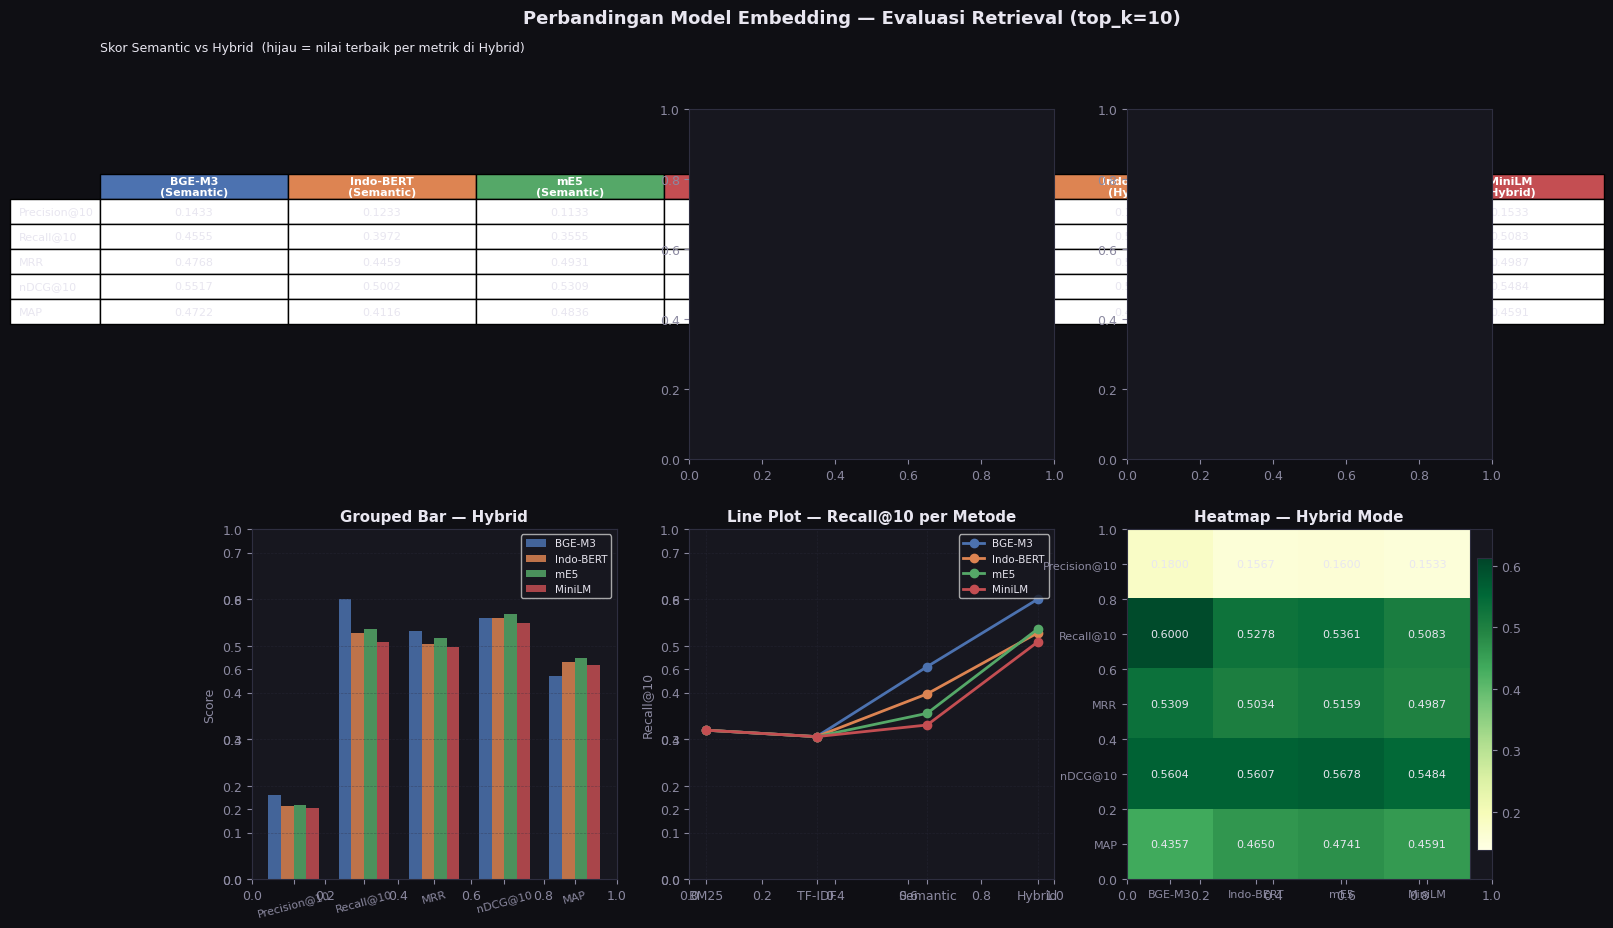

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── DATA ──────────────────────────────────────────────────────────────────────

models  = ["BGE-M3", "Indo-BERT", "mE5", "MiniLM"]
methods = ["BM25", "TF-IDF", "Semantic", "Hybrid"]
metrics = ["Precision@10", "Recall@10", "MRR", "nDCG@10", "MAP"]

data = {
    "BGE-M3":    {"Precision@10": [0.0967,0.0933,0.1433,0.1800],
                  "Recall@10":    [0.3194,0.3056,0.4555,0.6000],
                  "MRR":          [0.4198,0.3981,0.4768,0.5309],
                  "nDCG@10":      [0.4302,0.4166,0.5517,0.5604],
                  "MAP":          [0.3817,0.3553,0.4722,0.4357]},
    "Indo-BERT": {"Precision@10": [0.0967,0.0933,0.1233,0.1567],
                  "Recall@10":    [0.3194,0.3056,0.3972,0.5278],
                  "MRR":          [0.4198,0.3981,0.4459,0.5034],
                  "nDCG@10":      [0.4302,0.4166,0.5002,0.5607],
                  "MAP":          [0.3817,0.3553,0.4116,0.4650]},
    "mE5":       {"Precision@10": [0.0967,0.0933,0.1133,0.1600],
                  "Recall@10":    [0.3194,0.3056,0.3555,0.5361],
                  "MRR":          [0.4198,0.3981,0.4931,0.5159],
                  "nDCG@10":      [0.4302,0.4166,0.5309,0.5678],
                  "MAP":          [0.3817,0.3553,0.4836,0.4741]},
    "MiniLM":    {"Precision@10": [0.0967,0.0933,0.1033,0.1533],
                  "Recall@10":    [0.3194,0.3056,0.3305,0.5083],
                  "MRR":          [0.4198,0.3981,0.4275,0.4987],
                  "nDCG@10":      [0.4302,0.4166,0.4621,0.5484],
                  "MAP":          [0.3817,0.3553,0.4099,0.4591]},
}

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# ── FIGURE ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Perbandingan Model Embedding — Evaluasi Retrieval (top_k=10)",
             fontsize=13, fontweight="bold")

# ── 1. TABEL (baris atas, span semua kolom) ───────────────────────────────────

ax_tbl = axes[0, 0]
ax_tbl.set_position([0.03, 0.55, 0.94, 0.38])
ax_tbl.axis("off")

# Kolom: model x metode (Semantic & Hybrid saja supaya tidak terlalu lebar)
col_headers = []
for method in ["Semantic", "Hybrid"]:
    for model in models:
        col_headers.append(f"{model}\n({method})")

table_data = []
for metric in metrics:
    row = []
    for method_idx in [2, 3]:
        for model in models:
            row.append(f"{data[model][metric][method_idx]:.4f}")
    table_data.append(row)

tbl = ax_tbl.table(
    cellText=table_data,
    rowLabels=metrics,
    colLabels=col_headers,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)

# Warna header kolom sesuai warna model
for col_idx in range(len(col_headers)):
    model_idx = col_idx % len(models)
    tbl[(0, col_idx)].set_facecolor(colors[model_idx])
    tbl[(0, col_idx)].set_text_props(color="white", fontweight="bold")

# Highlight nilai tertinggi di kolom Hybrid per metrik
for row_idx in range(len(metrics)):
    hybrid_vals = [float(table_data[row_idx][4 + i]) for i in range(4)]
    best = int(np.argmax(hybrid_vals))
    tbl[(row_idx + 1, 4 + best)].set_facecolor("#d4edda")
    tbl[(row_idx + 1, 4 + best)].set_text_props(fontweight="bold")

ax_tbl.set_title("Skor Semantic vs Hybrid  (hijau = nilai terbaik per metrik di Hybrid)",
                 fontsize=9, loc="left", pad=6)

# ── 2. GROUPED BAR — Hybrid ───────────────────────────────────────────────────

ax1 = fig.add_subplot(2, 3, 4)
x     = np.arange(len(metrics))
width = 0.18

for i, model in enumerate(models):
    vals = [data[model][m][3] for m in metrics]
    ax1.bar(x + (i - 1.5) * width, vals, width,
            label=model, color=colors[i], alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=8, rotation=15)
ax1.set_ylabel("Score")
ax1.set_title("Grouped Bar — Hybrid", fontweight="bold")
ax1.legend(fontsize=7.5)
ax1.set_ylim(0, 0.75)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ── 3. LINE PLOT — Recall@10 per metode ──────────────────────────────────────

ax2 = fig.add_subplot(2, 3, 5)

for i, model in enumerate(models):
    vals = [data[model]["Recall@10"][j] for j in range(4)]
    ax2.plot(methods, vals, marker="o", color=colors[i],
             linewidth=2, markersize=6, label=model)

ax2.set_ylabel("Recall@10")
ax2.set_title("Line Plot — Recall@10 per Metode", fontweight="bold")
ax2.legend(fontsize=7.5)
ax2.set_ylim(0, 0.75)
ax2.grid(linestyle="--", alpha=0.4)

# ── 4. HEATMAP — Hybrid mode ──────────────────────────────────────────────────

ax3 = fig.add_subplot(2, 3, 6)

matrix = np.array([
    [data[model][metric][3] for model in models]
    for metric in metrics
])

im = ax3.imshow(matrix, cmap="YlGn", aspect="auto",
                vmin=matrix.min() * 0.9, vmax=matrix.max() * 1.02)

ax3.set_xticks(range(len(models)))
ax3.set_xticklabels(models, fontsize=8)
ax3.set_yticks(range(len(metrics)))
ax3.set_yticklabels(metrics, fontsize=8)
ax3.set_title("Heatmap — Hybrid Mode", fontweight="bold")

for r in range(len(metrics)):
    for c in range(len(models)):
        ax3.text(c, r, f"{matrix[r, c]:.4f}",
                 ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax3, fraction=0.04, pad=0.02)

# ── SIMPAN ────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig("retrieval_comparison.png", dpi=150, bbox_inches="tight")
print("Tersimpan: retrieval_comparison.png")
plt.show()